# 01 · Corners: who touches it first, is a shot coming, and how should we defend?

M1 replicates the core of TacticAI on open data:
1. **Receiver prediction:** which visible player makes the first touch (node classification)?
2. **Shot prediction:** does the corner lead to a shot within 20 s (graph classification)?
3. **Defensive suggestions:** small defender moves that lower the attackers' first-touch chance.

Models were trained by `scripts/train_corners.py`. Choices were made on validation, and
**test = Euro 2024**, scored once. All intervals are 95% cluster-bootstrap CIs over matches.

In [1]:
import json, numpy as np, pandas as pd, matplotlib.pyplot as plt, torch
from pathlib import Path
from IPython.display import display, Markdown
from sklearn.metrics import roc_auc_score
from phds.data.freeze_frames import PROCESSED_DIR
from phds.features.corner_graph import CornerGraphs
from phds.models.corner_gnn import CornerGNN
from phds.models.defence_search import suggest_defence, p_attack
from phds.eval.metrics import fmt_ci, reliability_bins, cluster_bootstrap

OUT = Path("../reports/m1"); OUT.mkdir(parents=True, exist_ok=True)
res = {s: json.loads((OUT / f"results_{s}.json").read_text()) for s in ["val", "test"]}
g = CornerGraphs.load(PROCESSED_DIR / "corner_graphs.npz")
test = g.subset(np.flatnonzero(g.meta["split"].to_numpy() == "test"))
pred = np.load(OUT / "predictions_test.npz", allow_pickle=True)
assert (pred["event_id"] == test.meta["event_id"].to_numpy()).all()

## 1. Receiver prediction

In [2]:
def recv_table(r):
    rows = [{"model": m["model"], "top-1 %": fmt_ci(m["top1"], True), "top-3 %": fmt_ci(m["top3"], True),
             "NLL": f"{m['nll'][0]:.3f}", "top-3 attack %": f"{100*m['top3_attack']:.1f}",
             "top-3 defence %": f"{100*m['top3_defence']:.1f}"} for m in r["receiver"]]
    return pd.DataFrame(rows).set_index("model")
for s in ["val", "test"]:
    display(Markdown(f"**{s}**: {res[s]['n_eval_receiver']} corners with a confident label"))
    display(recv_table(res[s]))

**val**: 192 corners with a confident label

,top-1 %,top-3 %,NLL,top-3 attack %,top-3 defence %
model,,,,,
uniform,"5.8 [5.7, 6.0]","17.5 [17.0, 18.0]",2.850,17.4,17.6
hotspot_hard,"7.8 [4.7, 11.6]","23.4 [17.8, 29.7]",3.050,5.9,37.4
lgbm_hard,"29.2 [22.5, 35.8]","52.6 [43.6, 61.3]",2.337,42.4,60.7
gnn_hard,"31.8 [25.3, 38.5]","53.1 [44.9, 60.9]",2.302,36.5,66.4
hotspot_hybrid,"8.3 [5.2, 12.2]","20.3 [16.1, 25.1]",3.174,4.7,32.7
lgbm_hybrid,"32.3 [24.9, 39.5]","50.5 [42.4, 58.7]",2.413,35.3,62.6
gnn_hybrid,"32.8 [25.7, 40.2]","51.6 [43.8, 59.6]",2.400,32.9,66.4


**test**: 165 corners with a confident label

,top-1 %,top-3 %,NLL,top-3 attack %,top-3 defence %
model,,,,,
uniform,"5.4 [5.4, 5.5]","16.3 [16.1, 16.5]",2.914,16.3,16.3
hotspot_hard,"3.6 [0.7, 7.0]","18.2 [11.6, 24.9]",2.998,3.5,34.2
lgbm_hard,"28.5 [21.2, 35.9]","50.9 [43.6, 58.1]",2.330,36.0,67.1
gnn_hard,"26.1 [20.1, 32.1]","55.2 [48.0, 62.7]",2.305,40.7,70.9
hotspot_hybrid,"4.8 [1.9, 8.2]","13.3 [7.7, 19.6]",3.203,2.3,25.3
lgbm_hybrid,"26.7 [20.1, 33.1]","53.3 [46.1, 60.4]",2.426,37.2,70.9
gnn_hybrid,"30.3 [23.7, 36.5]","48.5 [41.2, 56.0]",2.366,30.2,68.4


In [3]:
pd.DataFrame({s: {k: fmt_ci(v) for k, v in res[s]["comparisons"].items()} for s in ["val", "test"]})

,val,test
receiver top3: gnn_hybrid - lgbm_hybrid,"0.010 [-0.042, 0.062]","-0.048 [-0.106, 0.012]"
receiver top3: gnn_hard - lgbm_hard,"0.005 [-0.039, 0.050]","0.042 [-0.006, 0.095]"
receiver top3: gnn_hybrid - gnn_hard,"-0.016 [-0.060, 0.038]","-0.067 [-0.123, -0.010]"
receiver top3: lgbm_hybrid - lgbm_hard,"-0.021 [-0.075, 0.032]","0.024 [-0.020, 0.073]"
receiver top3: lgbm_hybrid - hotspot_hybrid,"0.302 [0.203, 0.394]","0.400 [0.308, 0.491]"
shot log loss: gnn_hybrid - lgbm,"-0.004 [-0.025, 0.017]","0.000 [-0.019, 0.018]"
shot log loss: lgbm - base_rate,"0.008 [-0.017, 0.034]","-0.023 [-0.044, -0.003]"
shot log loss: gnn_hybrid - base_rate,"0.004 [-0.020, 0.029]","-0.023 [-0.045, -0.002]"


### Does the model know *which team* wins the first touch?
This uses every corner with a detected first touch, including the ones with an ambiguous
player, because the *team* is known even when the individual isn't. It's the quantity the
defensive search optimises, so it needs to carry signal.

In [4]:
has_team = test.meta["label_team"].notna().to_numpy()
y_att = (test.meta["label_team"] == "attack").to_numpy()[has_team]
rows = []
for name in ["uniform", "hotspot_hybrid", "lgbm_hard", "lgbm_hybrid", "gnn_hard", "gnn_hybrid"]:
    pa_ = p_attack(pred[f"recv_{name}"], test.x)[has_team]
    groups = test.meta["match_id"].to_numpy()[has_team]
    ci = cluster_bootstrap(lambda i: roc_auc_score(y_att[i], pa_[i]) if 0 < y_att[i].sum() < len(i) else np.nan,
                           groups, n_boot=1000)
    rows.append({"model": name, "AUC P(attack first touch)": fmt_ci(ci), "mean P(attack)": round(pa_.mean(), 3),
                 "observed attack share": round(y_att.mean(), 3)})
display(pd.DataFrame(rows).set_index("model"))

# Paired: same resampled matches for both models.
def auc_diff(a, b):
    pa, pb = (p_attack(pred[f"recv_{m}"], test.x)[has_team] for m in (a, b))
    f = lambda i: (roc_auc_score(y_att[i], pa[i]) - roc_auc_score(y_att[i], pb[i])) if 0 < y_att[i].sum() < len(i) else np.nan
    return fmt_ci(cluster_bootstrap(f, groups, n_boot=1000))
print("AUC gnn_hard - lgbm_hard:", auc_diff("gnn_hard", "lgbm_hard"))
print("AUC gnn_hybrid - lgbm_hybrid:", auc_diff("gnn_hybrid", "lgbm_hybrid"))

,AUC P(attack first touch),mean P(attack),observed attack share
model,,,
uniform,"0.466 [0.397, 0.534]",0.414,0.464
hotspot_hybrid,"0.479 [0.396, 0.557]",0.376,0.464
lgbm_hard,"0.565 [0.497, 0.630]",0.443,0.464
lgbm_hybrid,"0.576 [0.515, 0.633]",0.421,0.464
gnn_hard,"0.647 [0.580, 0.714]",0.438,0.464
gnn_hybrid,"0.675 [0.610, 0.737]",0.406,0.464


AUC gnn_hard - lgbm_hard: 0.082 [0.024, 0.143]


AUC gnn_hybrid - lgbm_hybrid: 0.099 [0.030, 0.164]


### Example test corners: predicted first-touch probabilities

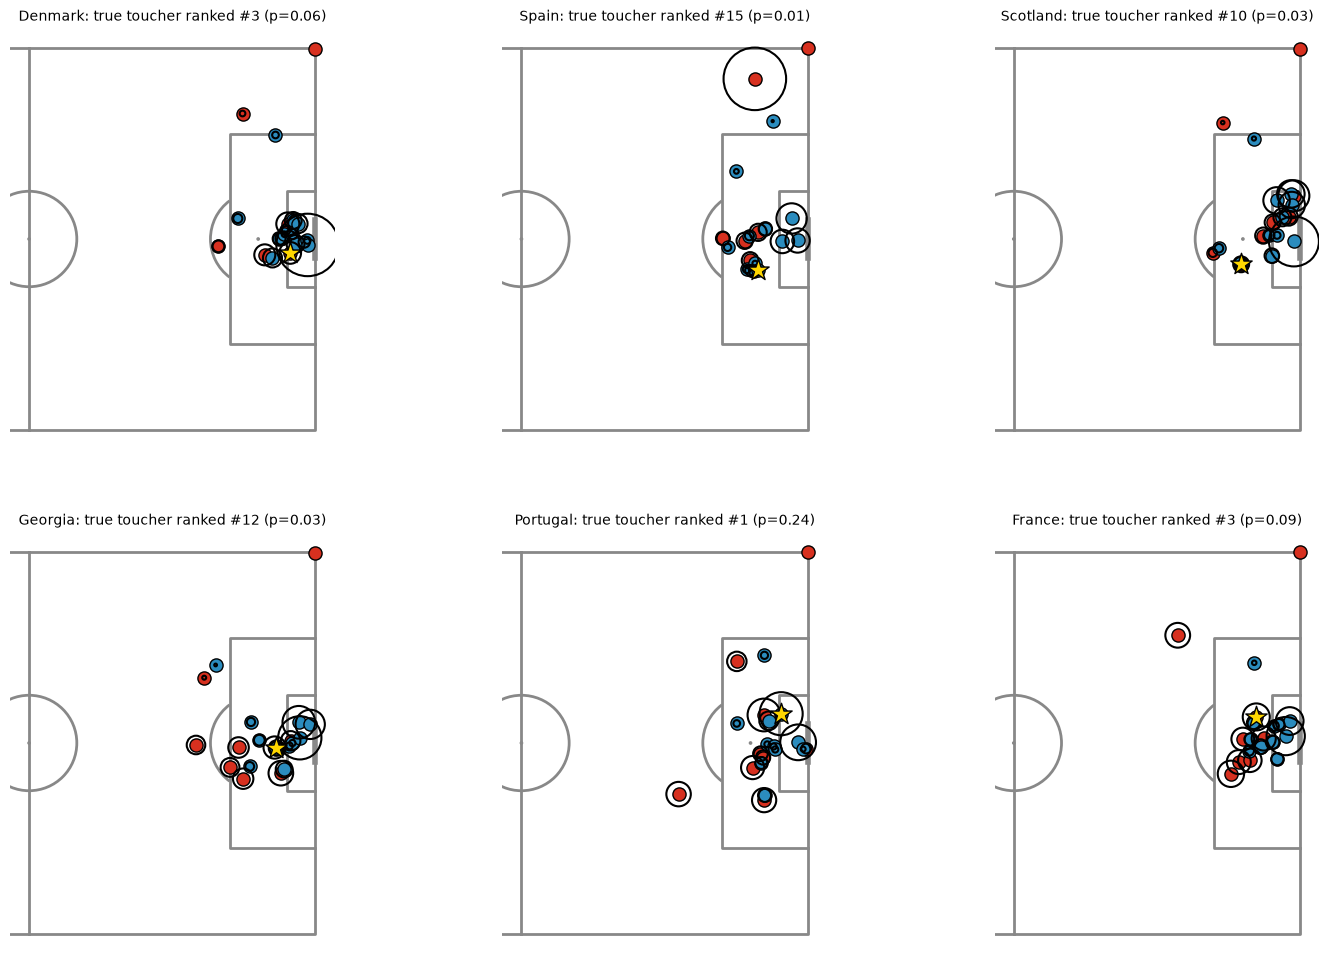

In [5]:
from mplsoccer import Pitch
best = "gnn_hard"
probs = pred[f"recv_{best}"]
ev = np.flatnonzero(test.target >= 0)
picks = np.random.default_rng(3).choice(ev, 6, replace=False)
pitch = Pitch(pitch_type="statsbomb", half=True, pitch_color="white", line_color="#888")
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
for ax, i in zip(axes.flat, picks):
    pitch.draw(ax=ax)
    n = test.mask[i].sum()
    xy = np.column_stack([test.x[i, :n, 0] * 120, test.x[i, :n, 1] * 80])
    att = test.x[i, :n, 2] == 1
    pitch.scatter(xy[att, 0], xy[att, 1], s=90, c="#d7301f", edgecolors="k", ax=ax, zorder=3)
    pitch.scatter(xy[~att, 0], xy[~att, 1], s=90, c="#2b8cbe", edgecolors="k", ax=ax, zorder=3)
    pitch.scatter(xy[:, 0], xy[:, 1], s=4000 * probs[i, :n], facecolors="none", edgecolors="k", lw=1.5, ax=ax, zorder=4)
    t = test.target[i]
    pitch.scatter(xy[t, 0], xy[t, 1], marker="*", s=260, c="gold", edgecolors="k", ax=ax, zorder=5)
    rank = int((probs[i] > probs[i, t]).sum()) + 1
    ax.set_title(f"{test.meta['team'].iloc[i]}: true toucher ranked #{rank} (p={probs[i, t]:.2f})", fontsize=10)
fig.savefig(OUT / "receiver_examples.png", dpi=130, bbox_inches="tight")

## 2. Shot prediction
Does the setup *at the moment of the kick* tell us whether a shot follows?

In [6]:
pd.DataFrame([{"model": m["model"], "log loss": fmt_ci(m["log_loss"]), "Brier": fmt_ci(m["brier"]),
               "AUC": fmt_ci(m["auc"]), "ECE": round(m["ece"], 3)} for m in res["test"]["shot"]]).set_index("model")

,log loss,Brier,AUC,ECE
model,,,,
base_rate,"0.644 [0.619, 0.671]","0.226 [0.213, 0.239]","0.500 [0.500, 0.500]",0.053
logistic,"0.636 [0.604, 0.672]","0.222 [0.207, 0.239]","0.570 [0.516, 0.621]",0.070
lgbm,"0.620 [0.586, 0.658]","0.216 [0.199, 0.233]","0.623 [0.552, 0.691]",0.051
gnn_hard,"0.624 [0.590, 0.660]","0.216 [0.201, 0.234]","0.621 [0.548, 0.689]",0.064
gnn_hybrid,"0.621 [0.594, 0.650]","0.215 [0.203, 0.229]","0.624 [0.554, 0.689]",0.071


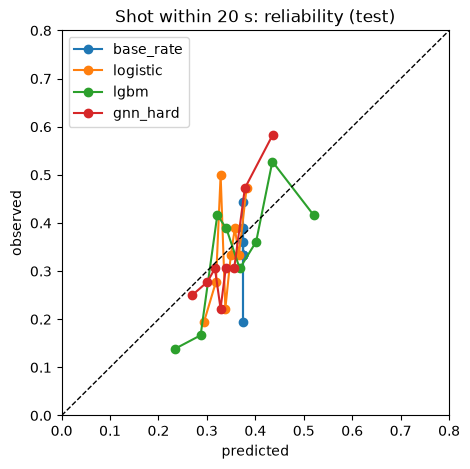

In [7]:
fig, ax = plt.subplots(figsize=(5, 5))
for name in ["base_rate", "logistic", "lgbm", "gnn_hard"]:
    rb = np.array(reliability_bins(pred[f"shot_{name}"], test.shot.astype(float), n_bins=8))
    ax.plot(rb[:, 0], rb[:, 1], "o-", label=name)
ax.plot([0, 1], [0, 1], "k--", lw=1); ax.set(xlim=(0, .8), ylim=(0, .8), xlabel="predicted", ylabel="observed",
        title="Shot within 20 s: reliability (test)")
ax.legend(); fig.savefig(OUT / "shot_reliability.png", dpi=150, bbox_inches="tight")

## 3. Defensive suggestions
Greedy constrained search (≤3 yd per defender, keeper fixed, ≥1 yd spacing) minimising
P(attackers win the first touch) under the hard-label GNN ensemble trained on train+val
(chosen on validation NLL: 2.30 vs 2.40 for soft labels).

In [8]:
models = []
for s in range(5):
    m = CornerGNN(test.x.shape[2], test.g.shape[1])
    m.load_state_dict(torch.load(PROCESSED_DIR / "models" / f"corner_gnn_hard_test_s{s}.pt"))
    models.append(m.eval())

def predictor(X, mask, cand, G):
    with torch.no_grad():
        ps = [torch.softmax(m(*(torch.as_tensor(a) for a in (X, mask, cand, G)))[0], -1).numpy() for m in models]
    return np.mean(ps, 0)

# Corners where the attackers are favoured to win the first touch: the ones a coach worries about.
pa_all = p_attack(pred["recv_gnn_hard"], test.x)
worry = np.argsort(-pa_all)[:40]
sugg = {int(i): suggest_defence(predictor, test.x[i], test.mask[i], test.cand[i], test.g[i]) for i in worry}
drops = pd.DataFrame([{"idx": i, "team": test.meta["team"].iloc[i], "before": s.p_attack_before,
                       "after": s.p_attack_after, "n_moves": len(s.moves),
                       "total_move_yd": np.linalg.norm(s.final_xy - s.start_xy, axis=1).sum()}
                      for i, s in sugg.items()])
drops["drop"] = drops["before"] - drops["after"]
display(drops.describe().round(3))

,idx,before,after,n_moves,total_move_yd,drop
count,40.00,40.000,40.000,40.000,40.000,40.000
mean,143.00,0.783,0.591,5.850,14.928,0.192
std,76.52,0.085,0.139,0.533,2.380,0.075
min,4.00,0.672,0.303,4.000,9.000,0.044
25%,96.75,0.704,0.494,6.000,14.000,0.147
50%,126.50,0.775,0.557,6.000,15.000,0.183
75%,222.75,0.843,0.708,6.000,17.000,0.228
max,266.00,0.943,0.899,6.000,18.000,0.403


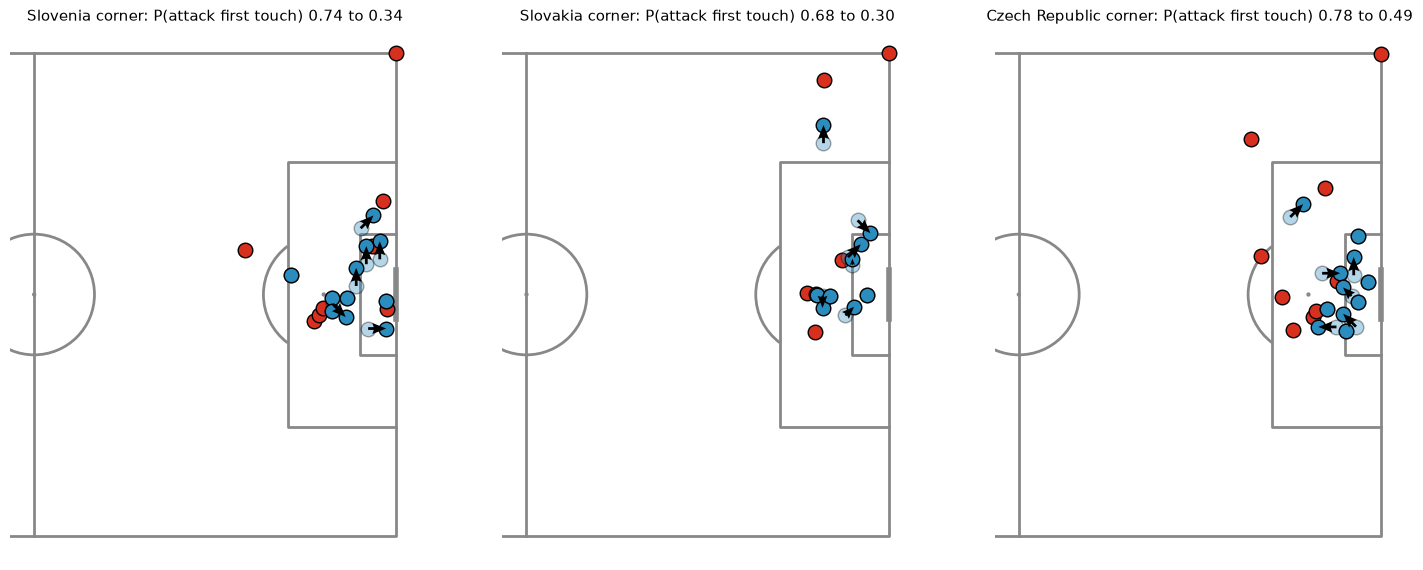

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(18, 7))
for ax, i in zip(axes, drops.sort_values("drop", ascending=False)["idx"].head(3)):
    s = sugg[i]; n = len(s.start_xy)
    att = test.x[i, :n, 2] == 1
    pitch.draw(ax=ax)
    pitch.scatter(s.start_xy[att, 0], s.start_xy[att, 1], s=110, c="#d7301f", edgecolors="k", ax=ax, zorder=3)
    pitch.scatter(s.start_xy[~att, 0], s.start_xy[~att, 1], s=110, c="#2b8cbe", alpha=.35, edgecolors="k", ax=ax, zorder=3)
    pitch.scatter(s.final_xy[~att, 0], s.final_xy[~att, 1], s=110, c="#2b8cbe", edgecolors="k", ax=ax, zorder=4)
    for j in np.flatnonzero(np.linalg.norm(s.final_xy - s.start_xy, axis=1) > 0):
        pitch.arrows(*s.start_xy[j], *s.final_xy[j], width=2, headwidth=4, color="k", ax=ax, zorder=5)
    ax.set_title(f"{test.meta['team'].iloc[i]} corner: P(attack first touch) {s.p_attack_before:.2f} to {s.p_attack_after:.2f}", fontsize=11)
fig.savefig(OUT / "defence_suggestions.png", dpi=130, bbox_inches="tight")

### Is the drop real, or is the search exploiting the model?
An optimiser pointed at a neural network will find inputs the network scores well, whether or not
they're genuinely better (the same mechanism as adversarial examples). Two checks:
* **Transfer:** re-score the suggested setups with models the search never saw: the soft-label
  GNN ensemble (different targets, different seeds) and LightGBM (a different model family).
  A real improvement should largely survive. An exploit should mostly vanish.
* **Random-move control:** the same number of defenders moved the same distances in random
  directions. If random moves also "help", the search found nothing.

In [10]:
from phds.features.corner_graph import node_features
from phds.models.defence_search import _graph_row, X_IDX, Y_IDX, ATT_IDX, TAKER_IDX, KEEPER_IDX
from phds.models import corner_baselines as B

def load_ensemble(regime):
    ms = []
    for s_ in range(5):
        m = CornerGNN(test.x.shape[2], test.g.shape[1])
        m.load_state_dict(torch.load(PROCESSED_DIR / "models" / f"corner_gnn_{regime}_test_s{s_}.pt"))
        ms.append(m.eval())
    return ms

def ensemble_predictor(ms):
    def f(X, mask, cand, G):
        with torch.no_grad():
            return np.mean([torch.softmax(m(*(torch.as_tensor(a) for a in (X, mask, cand, G)))[0], -1).numpy() for m in ms], 0)
    return f

# LightGBM (hard labels) retrained on train+val, exactly as in the test run.
trainval = g.subset(np.flatnonzero(g.meta["split"].to_numpy() != "test"))
dist = np.zeros(trainval.cand.shape, np.float32); has = trainval.target >= 0
dist[has, trainval.target[has]] = 1
lgbm = B.LGBMReceiver().fit(trainval, dist, has)
class _G:  # minimal CornerGraphs-like wrapper for predict()
    def __init__(s, x, mask, cand, g_): s.x, s.mask, s.cand, s.g = x, mask, cand, g_
lgbm_predictor = lambda X, mask, cand, G: lgbm.predict(_G(X, mask, cand, G))
scorers = {"gnn_hard (optimised)": predictor, "gnn_hybrid (independent)": ensemble_predictor(load_ensemble("hybrid")),
           "lgbm_hard (independent)": lgbm_predictor}

def config_arrays(i, xy):
    n = len(xy); x = test.x[i].copy(); gg = test.g[i].copy()
    att = x[:n, ATT_IDX] == 1; tak = x[:n, TAKER_IDX] == 1; kee = x[:n, KEEPER_IDX] == 1
    x[:n] = node_features(xy, att, tak, kee); gg = _graph_row(gg, xy, att)
    return x, gg

rng = np.random.default_rng(0)
def random_moves(i, s):
    # same defenders, same displacement lengths, random directions (respecting pitch bounds)
    xy = s.start_xy.copy()
    for j in np.flatnonzero(np.linalg.norm(s.final_xy - s.start_xy, axis=1) > 0):
        r = np.linalg.norm(s.final_xy[j] - s.start_xy[j]); a = rng.uniform(0, 2 * np.pi)
        xy[j] = np.clip(s.start_xy[j] + r * np.array([np.cos(a), np.sin(a)]), [0, 0], [120, 80])
    return xy

rows = []
for i, s in sugg.items():
    configs = {"before": s.start_xy, "suggested": s.final_xy, "random moves": random_moves(i, s)}
    for label, xy in configs.items():
        x, gg = config_arrays(i, xy)
        for sname, f in scorers.items():
            pa_ = p_attack(f(x[None], test.mask[i][None], test.cand[i][None], gg[None]), x[None])[0]
            rows.append({"corner": i, "config": label, "scorer": sname, "p_attack": pa_})
tr = pd.DataFrame(rows).pivot_table(index=["corner", "scorer"], columns="config", values="p_attack").reset_index()
tr["drop_suggested"] = tr["before"] - tr["suggested"]
tr["drop_random"] = tr["before"] - tr["random moves"]
summary = tr.groupby("scorer")[["before", "suggested", "random moves", "drop_suggested", "drop_random"]].mean().round(3)
opt = tr[tr.scorer.str.startswith("gnn_hard")].set_index("corner")["drop_suggested"]
summary["share of optimised drop retained"] = (summary["drop_suggested"] / opt.mean()).round(2)
display(summary)
groups_c = test.meta["match_id"].to_numpy()
for sname in scorers:
    d = tr[tr.scorer == sname].set_index("corner")
    diff = (d["drop_suggested"] - d["drop_random"]).to_numpy()
    ci = cluster_bootstrap(lambda idx: float(diff[idx].mean()), groups_c[d.index.to_numpy()], n_boot=1000)
    print(f"{sname:26s} suggested drop minus random-move drop: {fmt_ci(ci)}")
tr.to_csv(OUT / "defence_transfer.csv", index=False)

config,before,suggested,random moves,drop_suggested,drop_random,share of optimised drop retained
scorer,,,,,,
gnn_hard (optimised),0.783,0.591,0.776,0.192,0.006,1.00
gnn_hybrid (independent),0.725,0.552,0.724,0.173,0.001,0.90
lgbm_hard (independent),0.616,0.547,0.609,0.070,0.007,0.36


gnn_hard (optimised)       suggested drop minus random-move drop: 0.186 [0.148, 0.212]
gnn_hybrid (independent)   suggested drop minus random-move drop: 0.172 [0.129, 0.207]
lgbm_hard (independent)    suggested drop minus random-move drop: 0.062 [0.034, 0.082]


### Sanity check: do suggested moves make football sense?
If the model has learned something about marking, suggested moves should mostly bring defenders
*closer to attackers* rather than to arbitrary spots.

In [11]:
closer, total = 0, 0
for i, s in sugg.items():
    n = len(s.start_xy); att = test.x[i, :n, 2] == 1
    for j in np.flatnonzero(np.linalg.norm(s.final_xy - s.start_xy, axis=1) > 0):
        d0 = np.linalg.norm(s.start_xy[att] - s.start_xy[j], axis=1).min()
        d1 = np.linalg.norm(s.start_xy[att] - s.final_xy[j], axis=1).min()
        closer += d1 < d0; total += 1
print(f"moved defenders ending closer to their nearest attacker: {closer}/{total} ({closer/max(total,1):.0%})")

moved defenders ending closer to their nearest attacker: 123/228 (54%)


### So what *do* the moves do?
Canonical frame: corner taken from (120, 0), goal line at x = 120, near post at y = 36.

,dx_towards_goal_line,dy_towards_far_side,start_x,start_y,start_dist_to_taker
count,228.00,228.00,228.00,228.00,228.00
mean,0.51,-0.86,112.78,34.53,35.46
std,1.65,1.90,3.80,9.94,9.82
min,-3.00,-3.00,100.18,10.70,11.99
25%,0.00,-2.12,110.33,32.17,32.57
50%,0.00,-1.41,113.42,37.18,37.85
75%,2.12,0.00,115.52,40.93,41.71
max,3.00,3.00,120.08,54.66,54.58


moves toward the goal line: 47%; toward the near (corner) side: 61%; defenders in six-yard box before/after: 72 -> 101


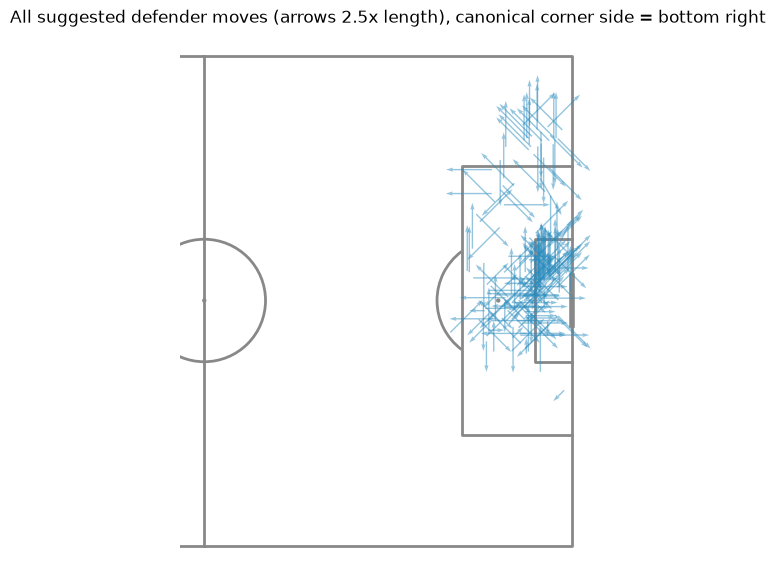

In [12]:
mv = []
for i, s in sugg.items():
    n = len(s.start_xy); att = test.x[i, :n, 2] == 1
    for j in np.flatnonzero(np.linalg.norm(s.final_xy - s.start_xy, axis=1) > 0):
        d = s.final_xy[j] - s.start_xy[j]
        mv.append({"dx_towards_goal_line": d[0], "dy_towards_far_side": d[1],
                   "start_x": s.start_xy[j, 0], "start_y": s.start_xy[j, 1],
                   "start_in_six": (s.start_xy[j, 0] >= 114) and (30 <= s.start_xy[j, 1] <= 50),
                   "end_in_six": (s.final_xy[j, 0] >= 114) and (30 <= s.final_xy[j, 1] <= 50),
                   "start_dist_to_taker": np.linalg.norm(s.start_xy[j] - s.start_xy[test.x[i, :n, 3] == 1][0])})
mv = pd.DataFrame(mv)
display(mv.describe().round(2))
print(f"moves toward the goal line: {(mv.dx_towards_goal_line > 0).mean():.0%}; "
      f"toward the near (corner) side: {(mv.dy_towards_far_side < 0).mean():.0%}; "
      f"defenders in six-yard box before/after: {mv.start_in_six.sum()} -> {mv.end_in_six.sum()}")
fig, ax = plt.subplots(figsize=(7, 7)); pitch.draw(ax=ax)
for _, r in mv.iterrows():
    pitch.arrows(r.start_x, r.start_y, r.start_x + 2.5 * r.dx_towards_goal_line, r.start_y + 2.5 * r.dy_towards_far_side,
                 width=1, headwidth=3, color="#2b8cbe", alpha=.5, ax=ax)
ax.set_title("All suggested defender moves (arrows 2.5x length), canonical corner side = bottom right")
fig.savefig(OUT / "defence_move_field.png", dpi=130, bbox_inches="tight")